Etape 1 : Ingestion et nettoyage des données

SPY → marché actions américain
QQQ → Nasdaq / tech / growth
TLT → obligations américaines long terme
GLD → or
USO → pétrole

In [1]:
import yfinance as yf

tickers = ["SPY", "TLT", "GLD", "USO", "QQQ"] 


data = yf.download(tickers, period="5y", auto_adjust=True)["Close"] #prix au close
data


[*********************100%***********************]  5 of 5 completed


Ticker,GLD,QQQ,SPY,TLT,USO
Date,,,,,
2021-09-02,169.250000,369.174164,423.565247,125.360283,48.950001
2021-09-03,171.059998,370.309601,423.462463,124.220200,48.660000
2021-09-07,167.710007,370.833649,421.948334,123.172356,48.040001
2021-09-08,167.289993,369.542908,421.434387,124.010612,48.590000
2021-09-09,168.029999,368.271637,419.630463,125.511269,47.750000
...,...,...,...,...,...
2026-08-27,422.600006,721.109985,771.099976,82.812668,130.009995
2026-08-28,408.890015,716.429993,769.349976,82.563622,129.699997
2026-08-31,408.420013,716.760010,767.049988,82.204994,133.699997


In [2]:
#rendements journaliers
returns = data.pct_change().dropna()  #on supprime la premiere ligne elle sera vide



#sauvegarde
returns.to_parquet("returns.parquet")

returns

Ticker,GLD,QQQ,SPY,TLT,USO
Date,,,,,
2021-09-03,0.010694,0.003076,-0.000243,-0.009094,-0.005924
2021-09-07,-0.019584,0.001415,-0.003576,-0.008435,-0.012741
2021-09-08,-0.002504,-0.003481,-0.001218,0.006806,0.011449
2021-09-09,0.004423,-0.003440,-0.004280,0.012101,-0.017288
2021-09-10,-0.005059,-0.007590,-0.007884,-0.008817,0.021990
...,...,...,...,...,...
2026-08-27,0.003038,0.013692,0.006553,-0.002041,0.020887
2026-08-28,-0.032442,-0.006490,-0.002269,-0.003007,-0.002384
2026-08-31,-0.001149,0.000461,-0.002990,-0.004344,0.030840


Etape 2 : Analyse exploratoire EDA

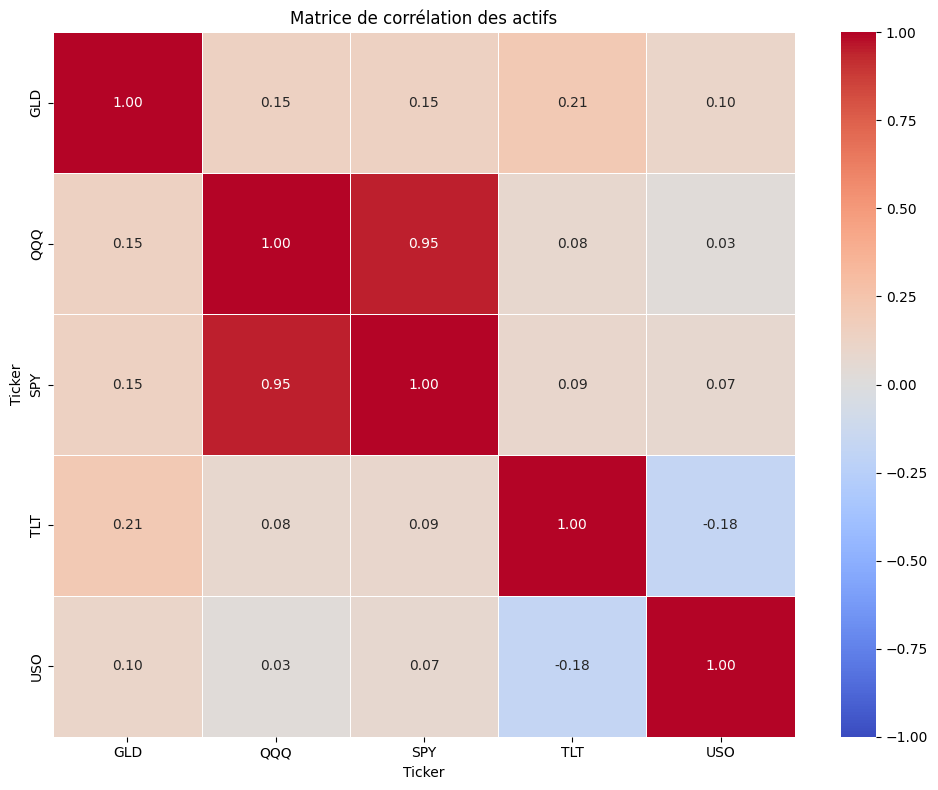

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

corr = returns.corr()

#matrice de correlation
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Matrice de corrélation des actifs")
plt.tight_layout()
plt.show()

On remarque qu'il n'ya presque pas de correlatrion entre les actifs (toute proche de 0), quoique les actions US et actions TECH sont évoluent fortement dans le même sens (0.95 proche de 1). Ce qui me semble logique car le marché des actions US est de loin majoritairement dominé par les grosses boîtes de TECH (NVIDIA, Apple, Microsoft...)

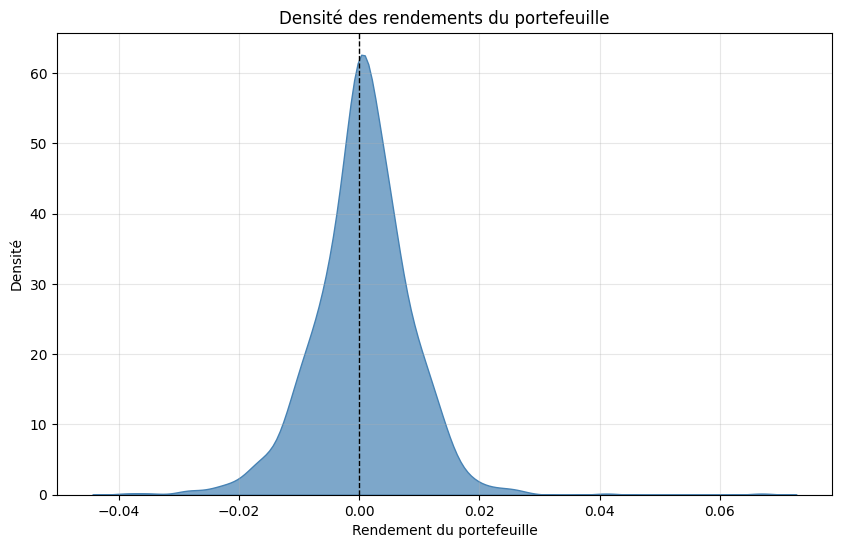

In [4]:
#courbe de densité des rendements du portefeuille
import numpy as np

# Portefeuille équipondéré 20%
poids = np.array([1/5, 1/5, 1/5, 1/5, 1/5])

#rendement du portefeuille  = somme pondérée des rendements
portfolio_return = returns.dot(poids)

# Courbe de densité
plt.figure(figsize=(10, 6))
sns.kdeplot(portfolio_return, fill="True", color="steelblue", alpha=0.7)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Densité des rendements du portefeuille")
plt.xlabel("Rendement du portefeuille")
plt.ylabel("Densité")
plt.grid(True, alpha=0.3)
plt.show()

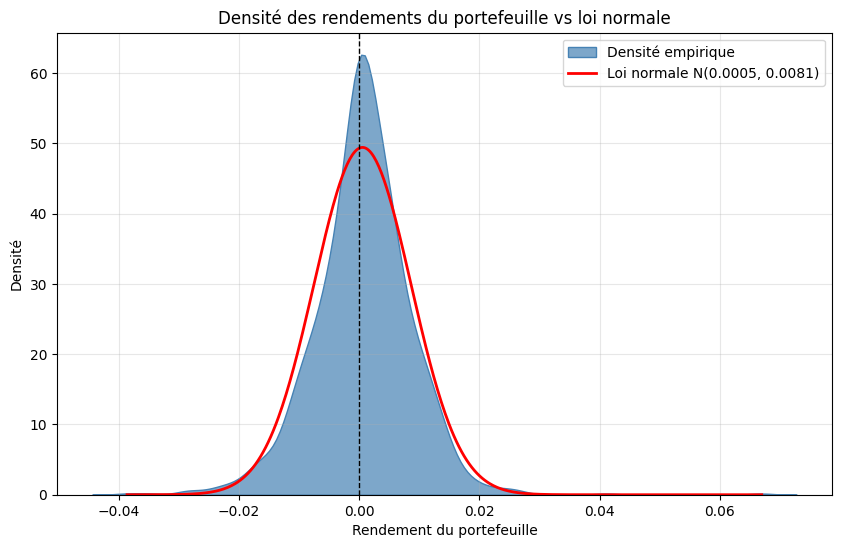

In [5]:
# superposition avec une loi normale de meme moyenne/ecart-type
from scipy import stats

#parametres de la loi normale
mu = portfolio_return.mean()
sigma = portfolio_return.std(ddof=1)

# Grille pour la courbe de densité normale
x = np.linspace(portfolio_return.min(), portfolio_return.max(), 500)

# Graphique
plt.figure(figsize=(10, 6))

# Densité empirique du portefeuille
sns.kdeplot(portfolio_return, fill=True, color="steelblue", alpha=0.7, label="Densité empirique")

# Loi normale de même moyenne / écart-type
plt.plot(
    x,
    stats.norm.pdf(x, loc=mu, scale=sigma),
    color="red",
    linewidth=2,
    label=f"Loi normale N({mu:.4f}, {sigma:.4f})"
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Densité des rendements du portefeuille vs loi normale")
plt.xlabel("Rendement du portefeuille")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Analyse de la distribution des rendements

Le pic de la densité des rendements du portfolio est 12% plus élevé que le pic d'une loi normale de même écart-type et de même moyenne. 
De plus, la densité des rendements du portfolio présente des queues légèrement plus épaisses que la loi normale.

In [6]:

# Skewness (asymétrie)
skewness = stats.skew(portfolio_return)

# Kurtosis (excès de kurtosis, par défaut dans scipy = Fisher)
kurtosis = stats.kurtosis(portfolio_return)

print(f"Skewness du portefeuille : {skewness:.6f}")
print(f"Kurtosis du portefeuille : {kurtosis:.6f}")

Skewness du portefeuille : 0.196379
Kurtosis du portefeuille : 5.076528


Le kurtosis est de 5,072775 soit 2 fois plus qu'une loi normale (généralement 3). 
Ce qui confirme les observations plus haut par rapports aux fat tails (les queues plus épaisses) et au pic central plus haut. 
Il en ressort que le portfolio est plutôt stable au quotidien avec des potentiels chocs extrêmes positifs comme négatifs plus important que ce que prévoit la normale. La skewness de 0.197325 indique qu'on devrait s'attendre plutôt à des chocs positifs.

Calcul de la VaR (3 méthodes)
Pour un horizon 1 jour, confiance 95% et 99% :

In [7]:
#VaR paramétrique
from scipy.stats import norm
#on suppose que les rendements du portfolio suivent une loi normale
# parametres : moyennne mu, quantile z, et volatilité sigma (ecart-type)

def calcul_var(returns_, confiance):
    mu = np.mean(returns_)
    z = norm.ppf(1 - confiance)
    sigma = np.std(returns_, ddof = 1)
    var = -(mu + z*sigma)
    return var

print("VaR paramétrique confiance 95 % : ", calcul_var(portfolio_return, 0.95))
print("VaR paramétrique confiance 99 % : ", calcul_var(portfolio_return, 0.99))

VaR paramétrique confiance 95 % :  0.012723162022099745
VaR paramétrique confiance 99 % :  0.018222220728817254


In [8]:
#var historique 
# le quantile empirique des rendements passés (pas d’hypothèse de distribution).
print(f"VaR historique confiance 95 % : {np.quantile(portfolio_return, 0.05)}" )
print(f"VaR historique confiance 99 % : {np.quantile(portfolio_return, 0.01)}" )

VaR historique confiance 95 % : -0.012299370663057089
VaR historique confiance 99 % : -0.020823176746523987


In [9]:
#var Monte Carlo
# Paramètres de simulation
n_scenarios = 10_000
confiances = [0.95, 0.99]

# Moyenne et covariance des rendements des actifs
mu_actifs = returns.mean().values  #pas le rendement du portefeuille mais celui des actifs
cov_actifs = returns.cov().values

# Simulation des rendements des actifs
simulations_actifs = np.random.multivariate_normal(
    mean=mu_actifs,
    cov=cov_actifs,
    size=n_scenarios
)

# Rendement simulé du portefeuille
simulations_portfolio = simulations_actifs.dot(poids)

for confiance in confiances:
    quantile = np.quantile(simulations_portfolio, 1 - confiance)
    var = -quantile
    
print(
    f"VaR Monte Carlo à {confiance:.0%} : "
    f"{var: }"
)

VaR Monte Carlo à 99% :  0.018951352166484754


| Niveau de confiance | VaR paramétrique | VaR historique | VaR Monte Carlo |
|---|---:|---:|---:|
| 95% | 1.2723% | 1.2299% | 1.2846% |
| 99% | 1.8222% | 2.0823% | 1.8951% |

La VaR à 99% donnée par la méthode historique est supérieure à celles données par les autres méthodes (1.82% < 1.85% <2.08%).

Il en ressort que le portfolio fait des pertes plus importantes que ce qui est attendu théoriquement. Les méthodes de calcul paramétrique et de Monte Carlo masquent la réalité car elles ne prennent pas en compte la tension réelle du marché. 

Rappelons que la méthode paramétrique suppose une distribution normale des rendements, la méthode Monte Carlo simule 10000 scénarios aléatoires possibles mais qui peuvent ne pas réfléter des comportements réels du portfolio. 

Nous allons backtester la VaR. 

Etape 4 : Backtesting de la VaR

backtest niveau de confiance 99%

In [13]:

"""
Compte les rendements inférieurs au seuil de perte de chaque VaR.
niveau de confiance 99%
Une exception correspond à : rendement réel < -VaR.
"""
VAR_PARAMETRIQUE_99 = 0.012723162022099745
VAR_HISTORIQUE_99 = 0.012299370663057089
VAR_MONTE_CARLO_99 = 0.018951352166484754

def calculer_exceptions(var, portfolio_return):
    return (portfolio_return < -var).sum()
    
print(f"Pour la méthode paramétrique, la perte réelle a dépassé la VaR prédite {calculer_exceptions(VAR_PARAMETRIQUE_99, portfolio_return)} fois")
        
print(f"Pour la méthode historique, la perte réelle a dépassé la VaR prédite {calculer_exceptions(VAR_HISTORIQUE_99, portfolio_return)} fois")

print(f"Pour la méthode Monte Carlo, la perte réelle a dépassé la VaR prédite {calculer_exceptions(VAR_MONTE_CARLO_99, portfolio_return)} fois")


Pour la méthode paramétrique, la perte réelle a dépassé la VaR prédite 58 fois
Pour la méthode historique, la perte réelle a dépassé la VaR prédite 63 fois
Pour la méthode Monte Carlo, la perte réelle a dépassé la VaR prédite 17 fois


backtest niveau de confiance 95%

In [14]:
"""
Compte les rendements inférieurs au seuil de perte de chaque VaR.
niveau de confiance 95%
Une exception correspond à : rendement réel < -VaR.
"""
VAR_PARAMETRIQUE_95 = 0.01822223008864799
VAR_HISTORIQUE_95 = 0.020823241379280686
VAR_MONTE_CARLO_95 = 0.01284682048312342

def calculer_exceptions(var, portfolio_return):
    return (portfolio_return < -var).sum()
    
print(f"Pour la méthode paramétrique, la perte réelle a dépassé la VaR prédite {calculer_exceptions(VAR_PARAMETRIQUE_95, portfolio_return)} fois")
        
print(f"Pour la méthode historique, la perte réelle a dépassé la VaR prédite {calculer_exceptions(VAR_HISTORIQUE_95, portfolio_return)} fois")

print(f"Pour la méthode Monte Carlo, la perte réelle a dépassé la VaR prédite {calculer_exceptions(VAR_MONTE_CARLO_95, portfolio_return)} fois")


Pour la méthode paramétrique, la perte réelle a dépassé la VaR prédite 19 fois
Pour la méthode historique, la perte réelle a dépassé la VaR prédite 13 fois
Pour la méthode Monte Carlo, la perte réelle a dépassé la VaR prédite 56 fois


TEST DE KUPIEC